# Seaborn Giriş

**Amaç:**
Bir önceki notebookda işlediğimiz **MATPLOTLIB** kütüphanesine ek olarak görselleştirme çalışmalarımız için **SEABORN** adlı kütüphaneden de sıklıkla faydalanırız. Seaborn kütüphanesi temelleri Matplotlib kütüphanesine dayanan bir kütüphanedir ve matplotlib kütüphanesinde yaptığımız tüm işlemleri Seaborn kütüphanesinde de yapabiliriz. Ancak Seaborn'un Matplotlib'e ek olarak bazı çok güzel özellikleri vardır.

**Veri Görselleştirmesi için Kullanılan Diğer Kütüphaneler:** _bokeh, ggplot, pygal, plotly, geoplotlib, gleam, missingno, leather_

Bu dersin sonunda şunları yapabiliyor olmayı hedefliyoruz:
1. **ViolinPlot**, **BoxPlot**, **JointPlot**, **Heatmap** gibi görsel ögeleri oluşturabilmek
2. **PairPlot** ve **FacetGrid** yöntemleriyle çoklu grafikler oluşturabilmek

## 1. Matplotlib

Öncelikle Matplotlib'de öğrendiklerimizi uygulamakla başlayalım...

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn import datasets
%matplotlib inline 

In [2]:
iris = datasets.load_iris() # Veri seti yükleme

dataset = pd.DataFrame(iris.data[:, :4], columns = iris.feature_names) # DataFrame oluşturma
dataset['target'] = iris.target # 0-'Setosa', 1-'Versicolor', 2-'Virginica'
dataset.target.replace(to_replace=[0,1,2], value=iris.target_names, inplace=True)

Veri seti içerisinden bir örneklem görelim.

In [3]:
dataset.sample(5)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
46,5.1,3.8,1.6,0.2,setosa
132,6.4,2.8,5.6,2.2,virginica
16,5.4,3.9,1.3,0.4,setosa
110,6.5,3.2,5.1,2.0,virginica
106,4.9,2.5,4.5,1.7,virginica


Matplotlib kütüphanesinde öğrendiklerimizi kullanarak 'Sepal Length' sütununa ait dağılımı inceleyelim.

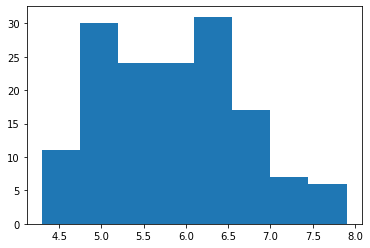

In [4]:
plt.hist(dataset['sepal length (cm)'], bins=8);

## 2. Seaborn

Şimdi de Seaborn kütüphanesini kullanarak aynı işlemi gerçekleştirelim.

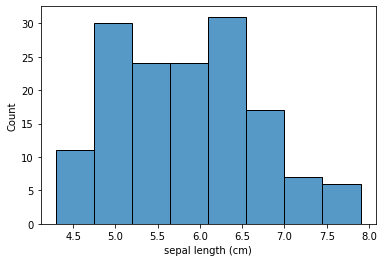

In [5]:
import seaborn as sns

sns.histplot(dataset['sepal length (cm)'], kde=False, bins=8);

Seaborn görselleştirmesi, grafik için biraz daha farklı bir biçimlendirmeye sahiptir. Bu konuda Matplotlib'den daha güzel varsayılanlara sahiptir.

### 2.1. Seaborn Temelleri

### 2.1.1. KDE Plot

Kernel Density Estimation (KDE), rastgele bir değişkenin olasılık yoğunluk fonksiyonunu tahmin etmenin parametrik olmayan bir yoludur. Bu görseli `kdeplot()` kullanarak çizdirebiliriz.

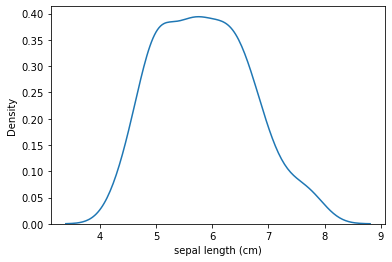

In [6]:
sns.kdeplot(dataset['sepal length (cm)']);

### 2.1.2. Barplot

Aynı Matplotlib'de yapabildiğimiz gibi `barplot()` kullanarak Bar Chartlar da oluşturabiliriz.

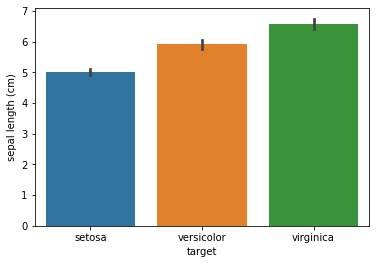

In [7]:
sns.barplot(x='target', y='sepal length (cm)', data=dataset);

### 2.1.3. Boxplot

Ve `boxplot()` kullanarak Box Plotlar...

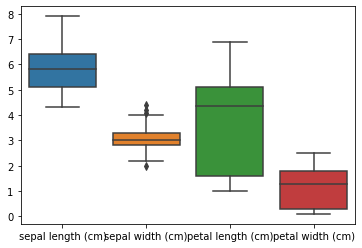

In [8]:
sns.boxplot(data=dataset);

- Yalnızca sayısal sütunları çizdiğini farketmişsinizdir (Kendisi **'str'** olduğu için **target** sütunumuza dair bilgi edinemiyoruz). Ancak bu çizdiremeyeceğimiz anlamına gelmiyor :) Bir de **target** sütunumuzu baz alarak Box Plot oluşturalım.

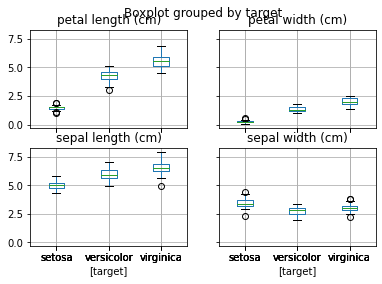

In [9]:
dataset.boxplot(by='target');

### 2.1.4. Violin Plot

Violin Plot görselleri de verdikleri çıktı bakımından Box Plot görsellerine çok benzerler. Violin Plotlar yoğunluk yaşanan değerleri daha güzel resmederken, Box Plotlar aykırı değerler(outliers) hakkında bilgi edinmemizi sağlarlar.

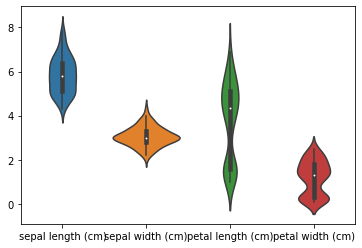

In [10]:
sns.violinplot(data=dataset);

### 2.1.5. PairPlot

PairPlot kendi içerisinde bir çok görsel öge oluşturarak, veri setimiz içerisinde bulunan her sayısal sütunun birbirleriyle kıyaslamamıza olanak sağlarlar.

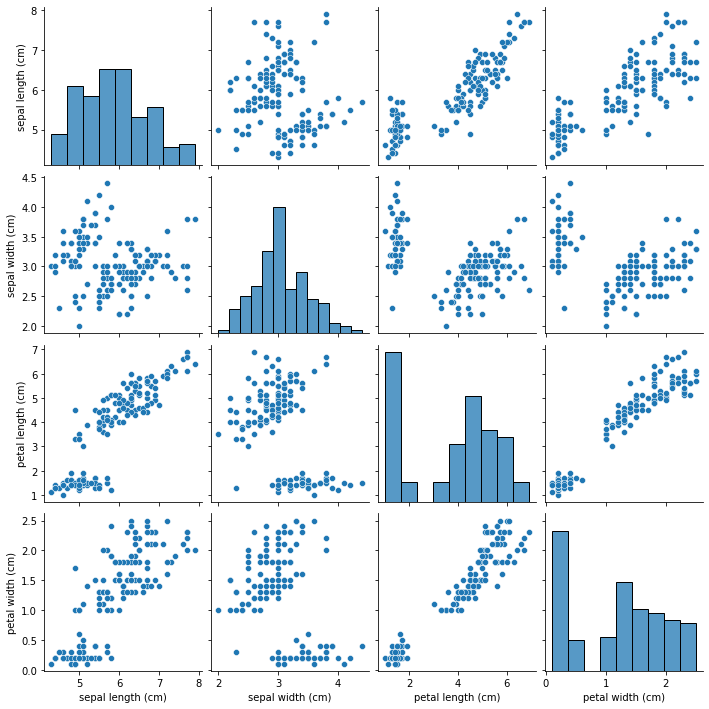

In [11]:
sns.pairplot(dataset);

### 2.1.6. Joint Plot

Joint Plot kıyasladığımız 2 değişken arasındaki ilişkiyi ve dağılımı aynı grafik üzerinde incelememize olanak sağlar.

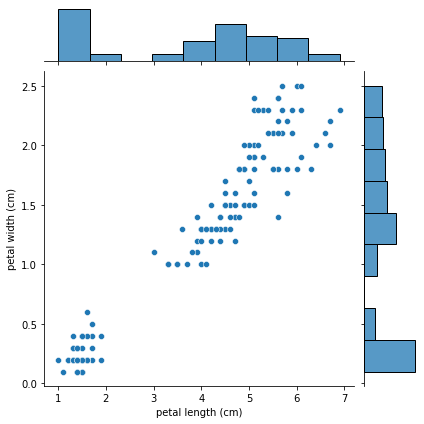

In [12]:
sns.jointplot(x="petal length (cm)", y="petal width (cm)", data=dataset);

### 2.1.7. Heatmap

Heatmap bir tabloda bulunan değerlere ait büyüklük/küçüklük ilişkilerine göre bir renklendirme yaparak sayısal değerleri birbiriyle kıyaslamamızda bize çok büyük bir rahatlık sağlar.

In [13]:
target_mean = dataset.groupby(by=['target']).mean()
target_mean

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
target,,,,
setosa,5.006,3.428,1.462,0.246
versicolor,5.936,2.770,4.260,1.326
virginica,6.588,2.974,5.552,2.026


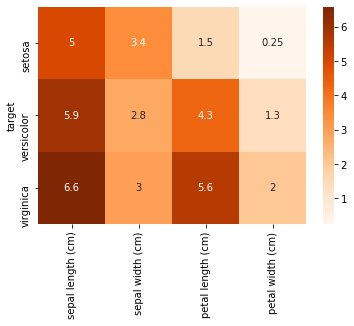

In [14]:
sns.heatmap(target_mean, cmap='Oranges', annot=True);

- Daha fazla **cmap** renk paleti için >>> https://matplotlib.org/3.5.0/tutorials/colors/colormaps.html

### 2.1.8. FacetGrid

Bu görsel yöntem bir veri kümesini, veri kümesindeki değişken seviyelerine karşılık gelen bir satır ve sütun ızgarasında dizilmiş birden çok eksene eşler.

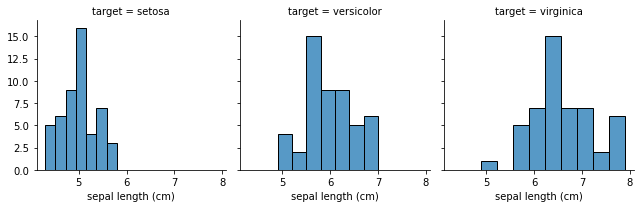

In [15]:
facetgrid = sns.FacetGrid(dataset, col='target')
facetgrid.map(sns.histplot, 'sepal length (cm)');

### 2.2. Son Değişiklikler

### 2.2.1. Arka Plan

Oluşturduğumuz grafikler için arka planı değiştirebiliriz.

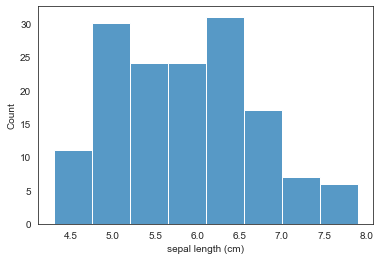

In [16]:
sns.set_style("white") # darkgrid, whitegrid, dark, white, ticks

sns.histplot(dataset['sepal length (cm)'], bins=8);

### 2.2.2. Despine

Aynı zamanda `despine()` fonksiyonunu kullanarak grafiğin üst ve sağ kısmında kalan sınırlayıcı çizgileri kaldırmak da mümkün.

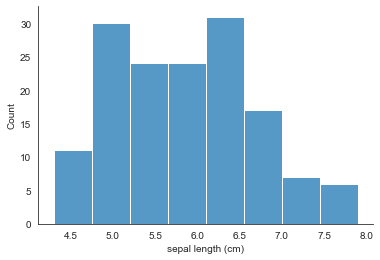

In [17]:
sns.histplot(dataset['sepal length (cm)'], bins=8);
sns.despine()

### 2.2.3. Renk Paletleri

Oluşturduğumuz tüm grafiklerde kullanılan renkleri amacımız doğrultusunda değiştirebiliriz. 
- Daha detaylı bilgi için >>> https://seaborn.pydata.org/tutorial/color_palettes.html

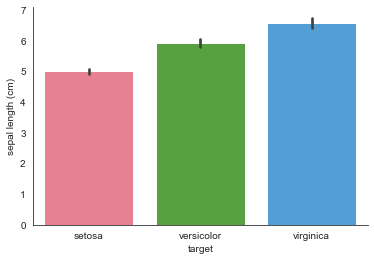

In [18]:
sns.barplot(x ='target', y='sepal length (cm)', data=dataset, palette = sns.color_palette("husl", 3));
sns.despine()

## Seaborn & Exploratory Data Analysis (EDA) Dökümanları

- [Seaborn](http://stanford.edu/~mwaskom/software/seaborn/)
- [Exploratory Data Analysis](https://www.amazon.com/Exploratory-Data-Analysis-John-Tukey/dp/0201076160)